# Day 6 — Predictions and Edge Inspection

Goal: inspect walk-forward model predictions and model-vs-market edge values.

Production logic lives in:

- `src/fbsystem/models/walk_forward.py`
- `src/fbsystem/features/edges.py`

Build script:

- `scripts/build_predictions.py`

Input:

- `data/processed/matches_with_market_probs.parquet`

Outputs:

- `data/processed/matches_with_predictions.parquet`
- `outputs/evaluation/predictions_report.csv`
- `outputs/evaluation/edge_report.csv`

This notebook does not create production transformations.

In [8]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

In [9]:
PROJECT_ROOT = Path("..").resolve()

PREDICTIONS_PATH = PROJECT_ROOT / "data" / "processed" / "matches_with_predictions.parquet"
PREDICTIONS_REPORT_PATH = PROJECT_ROOT / "outputs" / "evaluation" / "predictions_report.csv"
EDGE_REPORT_PATH = PROJECT_ROOT / "outputs" / "evaluation" / "edge_report.csv"

assert PREDICTIONS_PATH.exists(), f"Missing file: {PREDICTIONS_PATH}"
assert PREDICTIONS_REPORT_PATH.exists(), f"Missing file: {PREDICTIONS_REPORT_PATH}"
assert EDGE_REPORT_PATH.exists(), f"Missing file: {EDGE_REPORT_PATH}"

In [10]:
df = pd.read_parquet(PREDICTIONS_PATH)
predictions_report = pd.read_csv(PREDICTIONS_REPORT_PATH)
edge_report = pd.read_csv(EDGE_REPORT_PATH)

df.shape

(11511, 37)

In [11]:
predictions_report

,metric,value
0,n_prediction_rows,1.151100e+04
1,n_predicted_seasons,4.000000e+00
2,first_predicted_season,2.022000e+03
3,last_predicted_season,2.025000e+03
4,first_train_start_season,2.021000e+03
5,last_train_end_season,2.024000e+03
6,n_rows,1.151100e+04
7,accuracy,5.418296e-01
8,log_loss,1.478791e+00
9,mean_home_prob,4.498578e-01


In [12]:
edge_report

,metric,value
0,n_rows,11511.000000
1,mean_home_edge,0.010516
2,mean_draw_edge,-0.000967
3,mean_away_edge,-0.009548
4,min_home_edge,-0.075232
5,min_draw_edge,-0.073699
6,min_away_edge,-0.085046
7,max_home_edge,0.108943
8,max_draw_edge,0.058367
9,max_away_edge,0.095573


In [13]:
leakage_check = (
    df["prediction_train_end_season"] < df["prediction_test_season"]
)

leakage_check.value_counts()

True    11511
Name: count, dtype: int64

In [14]:
df.groupby("prediction_test_season").size()

prediction_test_season
2022    3086
2023    3016
2024    3016
2025    2393
dtype: int64

In [15]:
model_prob_cols = [
    "model_home_prob",
    "model_draw_prob",
    "model_away_prob",
]

prob_sums = df[model_prob_cols].sum(axis=1)

prob_sums.describe()

count    1.151100e+04
mean     1.000000e+00
std      6.691333e-17
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      1.000000e+00
dtype: float64

In [16]:
(prob_sums - 1).abs().max()

np.float64(2.220446049250313e-16)

In [17]:
comparison_summary = pd.DataFrame(
    {
        "market": [
            df["market_home_prob"].mean(),
            df["market_draw_prob"].mean(),
            df["market_away_prob"].mean(),
        ],
        "model": [
            df["model_home_prob"].mean(),
            df["model_draw_prob"].mean(),
            df["model_away_prob"].mean(),
        ],
    },
    index=["home", "draw", "away"],
)

comparison_summary

,market,model
home,0.439342,0.449858
draw,0.247884,0.246916
away,0.312774,0.303226


In [18]:
edge_cols = [
    "home_edge",
    "draw_edge",
    "away_edge"
]

df[edge_cols].describe()

,home_edge,draw_edge,away_edge
count,11511.000000,11511.000000,11511.000000
mean,0.010516,-0.000967,-0.009548
std,0.037711,0.026286,0.030231
min,-0.075232,-0.073699,-0.085046
25%,-0.019433,-0.020425,-0.030903
50%,0.007173,-0.000320,-0.015127
75%,0.035671,0.019513,0.009482
max,0.108943,0.058367,0.095573


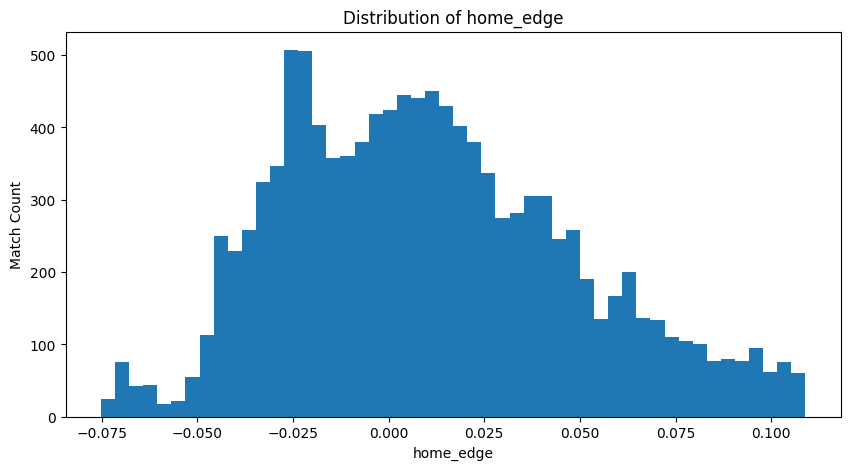

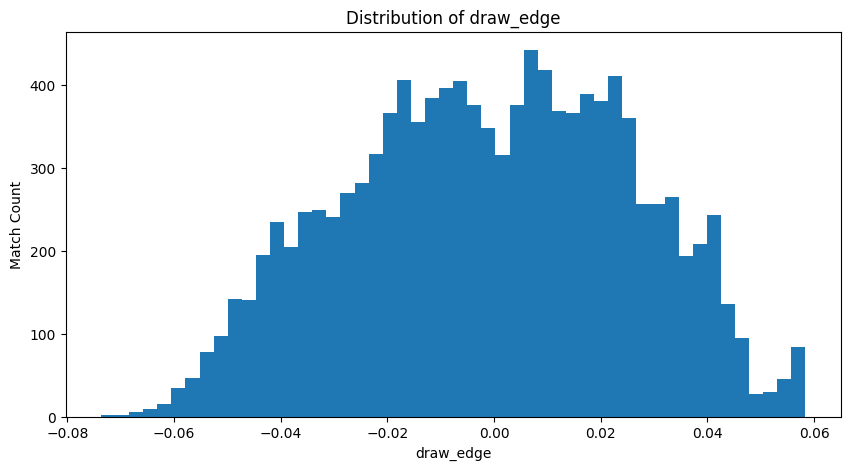

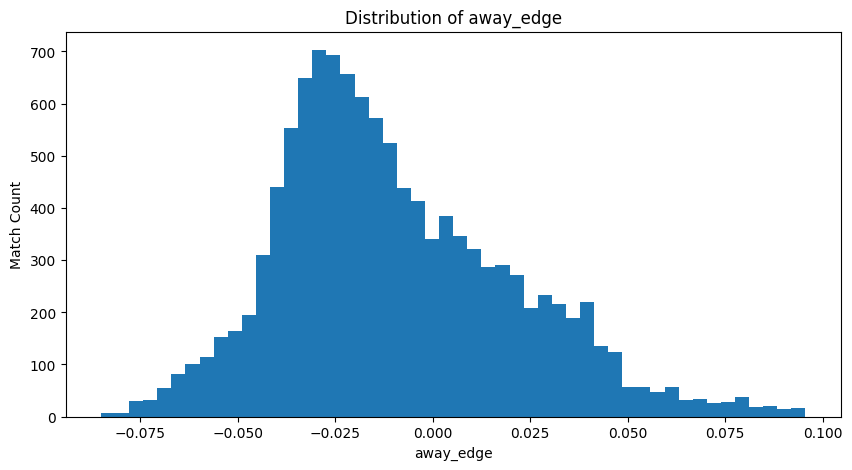

In [19]:
for col in edge_cols:
    plt.figure(figsize=(10, 5))
    plt.hist(df[col], bins=50)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Match Count")
    plt.show()

In [20]:
display_cols = [
    "match_date",
    "season",
    "source_country",
    "source_league_code",
    "home_team",
    "away_team",
    "full_time_result",
    "home_odds",
    "market_home_prob",
    "model_home_prob",
    "home_edge",
]

df[display_cols].sort_values("home_edge", ascending=False).head(20)

,match_date,season,source_country,source_league_code,home_team,away_team,full_time_result,home_odds,market_home_prob,model_home_prob,home_edge
5916,2024-05-11,2023-2024,england,E0,Newcastle,Brighton,D,1.59,0.604824,0.713767,0.108943
3399,2023-09-03,2023-2024,england,E0,Liverpool,Aston Villa,H,1.61,0.597230,0.705904,0.108673
6030,2024-05-19,2023-2024,england,E0,Crystal Palace,Aston Villa,H,1.66,0.579908,0.688445,0.108537
5766,2024-04-27,2023-2024,germany,D1,RB Leipzig,Dortmund,H,1.57,0.608905,0.717368,0.108463
4911,2024-02-10,2023-2024,england,E0,Tottenham,Brighton,H,1.74,0.552109,0.660550,0.108442
4254,2023-12-03,2023-2024,germany,D1,Leverkusen,Dortmund,D,1.63,0.588458,0.696607,0.108148
3433,2023-09-15,2023-2024,germany,D1,Bayern Munich,Leverkusen,D,1.59,0.603446,0.711592,0.108145
4311,2023-12-09,2023-2024,england,E0,Man United,Bournemouth,A,1.66,0.579163,0.687217,0.108054
5089,2024-02-24,2023-2024,germany,D1,Bayern Munich,RB Leipzig,H,1.76,0.545495,0.653537,0.108042
4546,2023-12-31,2023-2024,england,E0,Tottenham,Bournemouth,H,1.76,0.545199,0.653215,0.108016


In [22]:
display_cols = [
    "match_date",
    "season",
    "source_country",
    "source_league_code",
    "home_team",
    "away_team",
    "full_time_result",
    "home_odds",
    "market_home_prob",
    "model_home_prob",
    "away_edge",
]

df[display_cols].sort_values("away_edge", ascending=False).head(20)

,match_date,season,source_country,source_league_code,home_team,away_team,full_time_result,home_odds,market_home_prob,model_home_prob,away_edge
1775,2023-02-05,2022-2023,netherlands,N1,Groningen,Twente,D,5.62,0.168659,0.138144,0.095573
2379,2023-04-02,2022-2023,netherlands,N1,Sparta Rotterdam,Feyenoord,A,6.91,0.137892,0.116187,0.094968
1859,2023-02-12,2022-2023,netherlands,N1,Heerenveen,Feyenoord,A,5.81,0.163520,0.132852,0.094949
1602,2023-01-24,2022-2023,netherlands,N1,FC Emmen,PSV Eindhoven,H,6.55,0.144486,0.119296,0.094246
2298,2023-03-19,2022-2023,netherlands,N1,Vitesse,PSV Eindhoven,D,5.84,0.162249,0.130570,0.094022
2791,2023-05-06,2022-2023,netherlands,N1,Sparta Rotterdam,PSV Eindhoven,A,5.72,0.165952,0.132313,0.093354
383,2022-08-28,2022-2023,netherlands,N1,Volendam,Twente,H,5.55,0.170705,0.135669,0.093261
842,2022-10-09,2022-2023,netherlands,N1,Heerenveen,PSV Eindhoven,A,5.01,0.189199,0.151532,0.093232
725,2022-10-01,2022-2023,netherlands,N1,Groningen,AZ Alkmaar,A,4.83,0.196250,0.161798,0.092898
2343,2023-04-01,2022-2023,netherlands,N1,Nijmegen,PSV Eindhoven,A,4.89,0.194371,0.156062,0.092831


In [23]:
display_cols = [
    "match_date",
    "season",
    "source_country",
    "source_league_code",
    "home_team",
    "away_team",
    "full_time_result",
    "home_odds",
    "market_home_prob",
    "model_home_prob",
    "draw_edge",
]

df[display_cols].sort_values("draw_edge", ascending=False).head(20)

,match_date,season,source_country,source_league_code,home_team,away_team,full_time_result,home_odds,market_home_prob,model_home_prob,draw_edge
2006,2023-02-25,2022-2023,portugal,P1,Arouca,Casa Pia,H,2.39,0.396054,0.344567,0.058367
765,2022-10-02,2022-2023,portugal,P1,Rio Ave,Santa Clara,H,2.38,0.397058,0.345695,0.058345
1873,2023-02-13,2022-2023,portugal,P1,Boavista,Casa Pia,D,2.25,0.421053,0.369573,0.058334
678,2022-09-18,2022-2023,portugal,P1,Casa Pia,Famalicao,H,2.36,0.398727,0.347678,0.058263
393,2022-08-29,2022-2023,portugal,P1,Guimaraes,Casa Pia,A,2.28,0.414033,0.363493,0.058215
204,2022-08-14,2022-2023,portugal,P1,Boavista,Santa Clara,H,2.45,0.386125,0.334197,0.058180
1957,2023-02-19,2022-2023,portugal,P1,Casa Pia,Guimaraes,D,2.48,0.381750,0.329571,0.058081
1189,2022-11-07,2022-2023,portugal,P1,Chaves,Santa Clara,D,2.39,0.395143,0.344479,0.057994
2603,2023-04-22,2022-2023,portugal,P1,Boavista,Rio Ave,H,2.39,0.396671,0.346207,0.057966
2007,2023-02-25,2022-2023,portugal,P1,Maritimo,Santa Clara,H,2.22,0.426441,0.375687,0.057949
